In [3]:
# Cell 1: Plot chip centers with coastline (fix PROJ error)
import rasterio
from rasterio.warp import transform_bounds
import matplotlib.pyplot as plt
import geopandas as gpd
import glob
import os

In [ ]:
# Get all chips and transform bounds instead of points
chips_folder = '/discover/nobackup/ejalilva/data/irrigation_FM/training_chip_20/'
chip_files = glob.glob(f"{chips_folder}/cdl*.tif")

lons, lats = [], []
for i, chip_file in enumerate(chip_files):
    with rasterio.open(chip_file) as src:
        # Use transform_bounds instead of transform to avoid PROJ error
        bounds_4326 = transform_bounds(src.crs, 'EPSG:4326', *src.bounds)
        center_lon = (bounds_4326[0] + bounds_4326[2]) / 2
        center_lat = (bounds_4326[1] + bounds_4326[3]) / 2
        lons.append(center_lon)
        lats.append(center_lat)
    
    if (i + 1) % 50 == 0 or (i + 1) == len(chip_files):
        print(f"Processed {i+1}/{len(chip_files)} chips")

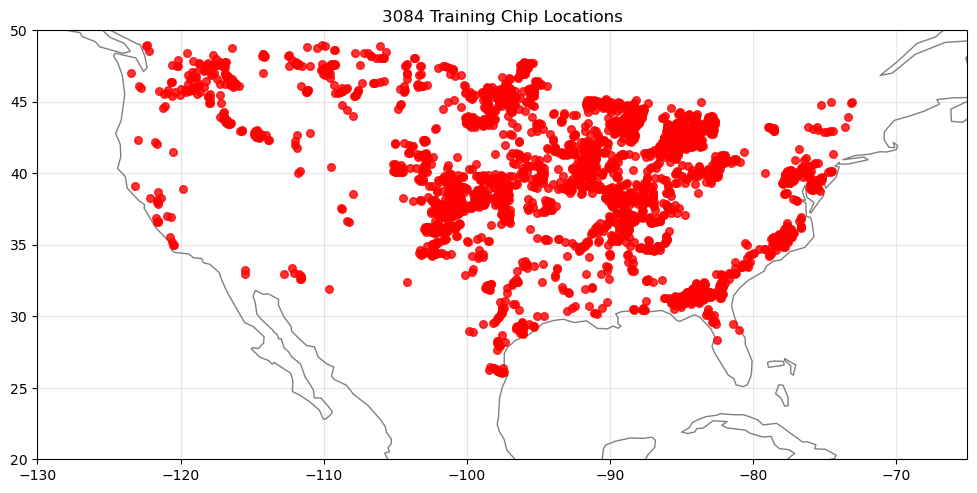

Plotted 3084 chips


In [3]:
# Plot with coastlines
fig, ax = plt.subplots(figsize=(12, 8))

# Plot coastlines
coastline_dir = '/discover/nobackup/ejalilva/data/coastline'
coast_shp = os.path.join(coastline_dir, 'ne_110m_coastline.shp')
coastline = gpd.read_file(coast_shp)
coastline.plot(ax=ax, edgecolor='gray', linewidth=1)

# Plot chip centers
ax.scatter(lons, lats, c='red', s=30, alpha=0.8, zorder=5)

ax.set_xlim(-130, -65)
ax.set_ylim(20, 50)
ax.set_title(f'{len(chip_files)} Training Chip Locations')
ax.grid(True, alpha=0.3)
plt.show()

print(f"Plotted {len(chip_files)} chips")

# finding overlapping chips with each lgrip tile

In [6]:
lgrip_dir = '/discover/nobackup/ejalilva/data/irrigation_FM'
lgrip_files = glob.glob(f"{lgrip_dir}/LGRIP30_*.tif")
overlaps = {}

for lgrip_file in lgrip_files:
    lgrip_name = os.path.basename(lgrip_file)
    with rasterio.open(lgrip_file) as src:
        bounds = src.bounds
    
    intersecting_chips = []
    for i, (lon, lat) in enumerate(zip(lons, lats)):
        if bounds.left <= lon <= bounds.right and bounds.bottom <= lat <= bounds.top:
            intersecting_chips.append(os.path.basename(chip_files[i]))
    
    overlaps[lgrip_name] = intersecting_chips
    print(f"{lgrip_name}: {len(intersecting_chips)} intersecting chips")

LGRIP30_L3_2020_N20W80_002_202408210000.tif: 0 intersecting chips
LGRIP30_L3_2020_N20W110_002_202408210000.tif: 0 intersecting chips
LGRIP30_L3_2020_N30W130_002_202408210000.tif: 18 intersecting chips
LGRIP30_L3_2020_N30W100_002_202408210000.tif: 482 intersecting chips
LGRIP30_L3_2020_N40W100_002_202408210000.tif: 446 intersecting chips
LGRIP30_L3_2020_N40W90_002_202408210000.tif: 609 intersecting chips
LGRIP30_L3_2020_N20W100_002_202408210000.tif: 55 intersecting chips
LGRIP30_L3_2020_N40W120_002_202408210000.tif: 165 intersecting chips
LGRIP30_L3_2020_N40W130_002_202408210000.tif: 26 intersecting chips
LGRIP30_L3_2020_N30W90_002_202408210000.tif: 562 intersecting chips
LGRIP30_L3_2020_N40W70_002_202408210000.tif: 0 intersecting chips
LGRIP30_L3_2020_N40W80_002_202408210000.tif: 59 intersecting chips
LGRIP30_L3_2020_N20W90_002_202408210000.tif: 7 intersecting chips
LGRIP30_L3_2020_N30W110_002_202408210000.tif: 284 intersecting chips
LGRIP30_L3_2020_N30W120_002_202408210000.tif: 11 int

In [9]:
import os
import rasterio
import numpy as np
from osgeo import gdal
from pathlib import Path
import pandas as pd

# Process the 4 recommended LGRIP tiles
recommended_tiles = [
    'LGRIP30_L3_2020_N40W100_002_202408210000.tif',  # High Plains
    'LGRIP30_L3_2020_N30W90_002_202408210000.tif',   # Mississippi  
    'LGRIP30_L3_2020_N40W120_002_202408210000.tif',  # Central Valley
    'LGRIP30_L3_2020_N40W90_002_202408210000.tif'    # Midwest
]

# Map tiles to region names
region_mapping = {
    'LGRIP30_L3_2020_N40W100_002_202408210000.tif': 'high_plains',
    'LGRIP30_L3_2020_N30W90_002_202408210000.tif': 'mississippi',  
    'LGRIP30_L3_2020_N40W120_002_202408210000.tif': 'central_valley',
    'LGRIP30_L3_2020_N40W90_002_202408210000.tif': 'midwest'
}

lgrip_dir = '/discover/nobackup/ejalilva/data/irrigation_FM'
output_dir = os.path.join(lgrip_dir,'ir_training_chips')
chips_folder = '/discover/nobackup/ejalilva/data/irrigation_FM/training_chip_20/'
os.makedirs(output_dir, exist_ok=True)
gdal.UseExceptions()

for tile_name in recommended_tiles:
    # Create region-specific folder
    region_name = region_mapping[tile_name]
    region_output_dir = os.path.join(output_dir, region_name)
    os.makedirs(region_output_dir, exist_ok=True)
    
    lgrip_file = os.path.join(lgrip_dir, tile_name)
    intersecting_chips = overlaps[tile_name]
    
    print(f"\n=== Processing {tile_name} ({region_name}) ===")
    print(f"Processing {len(intersecting_chips)} chips")
    
    # Track processed chips for this region
    processed_chips = []
    
    for i, chip_name in enumerate(intersecting_chips):
        chip_path = os.path.join(chips_folder, chip_name)
        
        try:
            # Load CDL chip
            with rasterio.open(chip_path) as cdl_src:
                cdl_data = cdl_src.read(1)
                profile = cdl_src.profile
                
                # Get CDL properties for alignment
                cdl_ds = gdal.Open(chip_path)
                cdl_proj = cdl_ds.GetProjection()
                cdl_gt = cdl_ds.GetGeoTransform()
                x_pixels, y_pixels = cdl_ds.RasterXSize, cdl_ds.RasterYSize
                
                # Calculate bounds
                minx, maxy = cdl_gt[0], cdl_gt[3]
                pixel_size_x, pixel_size_y = abs(cdl_gt[1]), abs(cdl_gt[5])
                maxx = minx + (x_pixels * pixel_size_x)
                miny = maxy - (y_pixels * pixel_size_y)
                cdl_ds = None
                
                # Align LGRIP to CDL
                temp_output = f"/tmp/temp_lgrip_{i}.tif"
                warp_options = gdal.WarpOptions(
                    outputBounds=[minx, miny, maxx, maxy],
                    width=x_pixels, height=y_pixels,
                    dstSRS=cdl_proj,
                    resampleAlg=gdal.GRA_NearestNeighbour,
                    dstNodata=0
                )
                gdal.Warp(temp_output, lgrip_file, options=warp_options)
                
                # Load aligned LGRIP
                with rasterio.open(temp_output) as lgrip_src:
                    lgrip_data = lgrip_src.read(1)
                
                # Apply masks
                water_mask = (cdl_data == 7)
                cropland_mask = np.isin(cdl_data, [3,4,8,9,11,12])
                irrigated_mask = (lgrip_data == 2)
                rainfed_mask = (lgrip_data == 3)
                
                # Combine conditions
                result = np.where(water_mask, 0,
                        np.where(cropland_mask & irrigated_mask, 1,
                        np.where(cropland_mask & rainfed_mask, 2, 3)))
                
                # Save result in region folder
                output_path = os.path.join(region_output_dir, chip_name)
                with rasterio.open(output_path, 'w', **profile) as dst:
                    dst.write(result.astype(profile['dtype']), 1)
                
                # Clean up
                os.remove(temp_output)
                
                # Track processed chip with both paths
                processed_chips.append({
                    'chip_name': chip_name,
                    'chip_path': chip_path,
                    'lgrip_path': lgrip_file,
                    'lgrip_name': tile_name,
                    'output_path': output_path
                })
                
                if (i + 1) % 10 == 0:
                    print(f"  Processed {i+1}/{len(intersecting_chips)} chips")
                    
        except Exception as e:
            print(f"  Error processing {chip_name}: {e}")
            continue
    
    # Write chip paths to files
    # Simple text file with both paths
    txt_file = os.path.join(region_output_dir, 'chip_paths.txt')
    with open(txt_file, 'w') as f:
        f.write("chip_path,lgrip_path\n")
        for chip_info in processed_chips:
            f.write(f"{chip_info['chip_path']},{chip_info['lgrip_path']}\n")
    
    # CSV file with more details
    csv_file = os.path.join(region_output_dir, 'chip_info.csv')
    df = pd.DataFrame(processed_chips)
    df.to_csv(csv_file, index=False)
    
    print(f"Completed {tile_name} -> {region_output_dir}")
    print(f"  Processed {len(processed_chips)} chips successfully")
    print(f"  Saved paths to: {txt_file} and {csv_file}")


=== Processing LGRIP30_L3_2020_N40W100_002_202408210000.tif (high_plains) ===
Processing 446 chips
  Processed 10/446 chips
  Processed 20/446 chips
  Processed 30/446 chips
  Processed 40/446 chips
  Processed 50/446 chips
  Processed 60/446 chips
  Processed 70/446 chips
  Processed 80/446 chips
  Processed 90/446 chips
  Processed 100/446 chips
  Processed 110/446 chips
  Processed 120/446 chips
  Processed 130/446 chips
  Processed 140/446 chips
  Processed 150/446 chips
  Processed 160/446 chips
  Processed 170/446 chips
  Processed 180/446 chips
  Processed 190/446 chips
  Processed 200/446 chips
  Processed 210/446 chips
  Processed 220/446 chips
  Processed 230/446 chips
  Processed 240/446 chips
  Processed 250/446 chips
  Processed 260/446 chips
  Processed 270/446 chips
  Processed 280/446 chips
  Processed 290/446 chips
  Processed 300/446 chips
  Processed 310/446 chips
  Processed 320/446 chips
  Processed 330/446 chips
  Processed 340/446 chips
  Processed 350/446 chips

In [ ]:
import os
import rasterio
import numpy as np
from osgeo import gdal
from pathlib import Path

# Process the 4 recommended LGRIP tiles
recommended_tiles = [
    'LGRIP30_L3_2020_N40W100_002_202408210000.tif',  # High Plains
    'LGRIP30_L3_2020_N30W90_002_202408210000.tif',   # Mississippi  
    'LGRIP30_L3_2020_N40W120_002_202408210000.tif',  # Central Valley
    'LGRIP30_L3_2020_N40W90_002_202408210000.tif'    # Midwest
]

lgrip_dir = '/discover/nobackup/ejalilva/data/irrigation_FM'
output_dir = os.path.join(lgrip_dir,'ir_training_chips')
chips_folder = '/discover/nobackup/ejalilva/data/irrigation_FM/training_chip_20/'
os.makedirs(output_dir, exist_ok=True)
gdal.UseExceptions()

for tile_name in recommended_tiles:
    lgrip_file = os.path.join(lgrip_dir, tile_name)
    intersecting_chips = overlaps[tile_name]
    
    print(f"\n=== Processing {tile_name} ===")
    print(f"Processing {len(intersecting_chips)} chips")
    
    for i, chip_name in enumerate(intersecting_chips):
        chip_path = os.path.join(chips_folder, chip_name)
        
        try:
            # Load CDL chip
            with rasterio.open(chip_path) as cdl_src:
                cdl_data = cdl_src.read(1)
                profile = cdl_src.profile
                
                # Get CDL properties for alignment
                cdl_ds = gdal.Open(chip_path)
                cdl_proj = cdl_ds.GetProjection()
                cdl_gt = cdl_ds.GetGeoTransform()
                x_pixels, y_pixels = cdl_ds.RasterXSize, cdl_ds.RasterYSize
                
                # Calculate bounds
                minx, maxy = cdl_gt[0], cdl_gt[3]
                pixel_size_x, pixel_size_y = abs(cdl_gt[1]), abs(cdl_gt[5])
                maxx = minx + (x_pixels * pixel_size_x)
                miny = maxy - (y_pixels * pixel_size_y)
                cdl_ds = None
                
                # Align LGRIP to CDL
                temp_output = f"/tmp/temp_lgrip_{i}.tif"
                warp_options = gdal.WarpOptions(
                    outputBounds=[minx, miny, maxx, maxy],
                    width=x_pixels, height=y_pixels,
                    dstSRS=cdl_proj,
                    resampleAlg=gdal.GRA_NearestNeighbour,
                    dstNodata=0
                )
                gdal.Warp(temp_output, lgrip_file, options=warp_options)
                
                # Load aligned LGRIP
                with rasterio.open(temp_output) as lgrip_src:
                    lgrip_data = lgrip_src.read(1)
                
                # Apply masks
                water_mask = (cdl_data == 7)
                cropland_mask = np.isin(cdl_data, [3,4,8,9,11,12])
                irrigated_mask = (lgrip_data == 2)
                rainfed_mask = (lgrip_data == 3)
                
                # Combine conditions
                result = np.where(water_mask, 0,
                        np.where(cropland_mask & irrigated_mask, 1,
                        np.where(cropland_mask & rainfed_mask, 2, 3)))
                
                # Save result
                output_path = os.path.join(output_dir, f"{tile_name[:-4]}_{chip_name}")
                with rasterio.open(output_path, 'w', **profile) as dst:
                    dst.write(result.astype(profile['dtype']), 1)
                
                # Clean up
                os.remove(temp_output)
                
                if (i + 1) % 10 == 0:
                    print(f"  Processed {i+1}/{len(intersecting_chips)} chips")
                    
        except Exception as e:
            print(f"  Error processing {chip_name}: {e}")
            continue
    
    print(f"Completed {tile_name}")

In [16]:
lgrip_dir = '/discover/nobackup/ejalilva/data/irrigation_FM'
import os
import glob
import rioxarray as rio
import rasterio
from rasterio.merge import merge
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
import pandas as pd
path_df = pd.read_csv(os.path.join(lgrip_dir,'ir_training_chips/central_valley','chip_info.csv'))
print(path_df.chip_path.iloc[0],'\n',path_df.output_path.iloc[0])

/discover/nobackup/ejalilva/data/irrigation_FM/training_chip_20/cdl_2020_chip_1547.tif 
 /discover/nobackup/ejalilva/data/irrigation_FM/ir_training_chips/central_valley/cdl_2020_chip_1547.tif


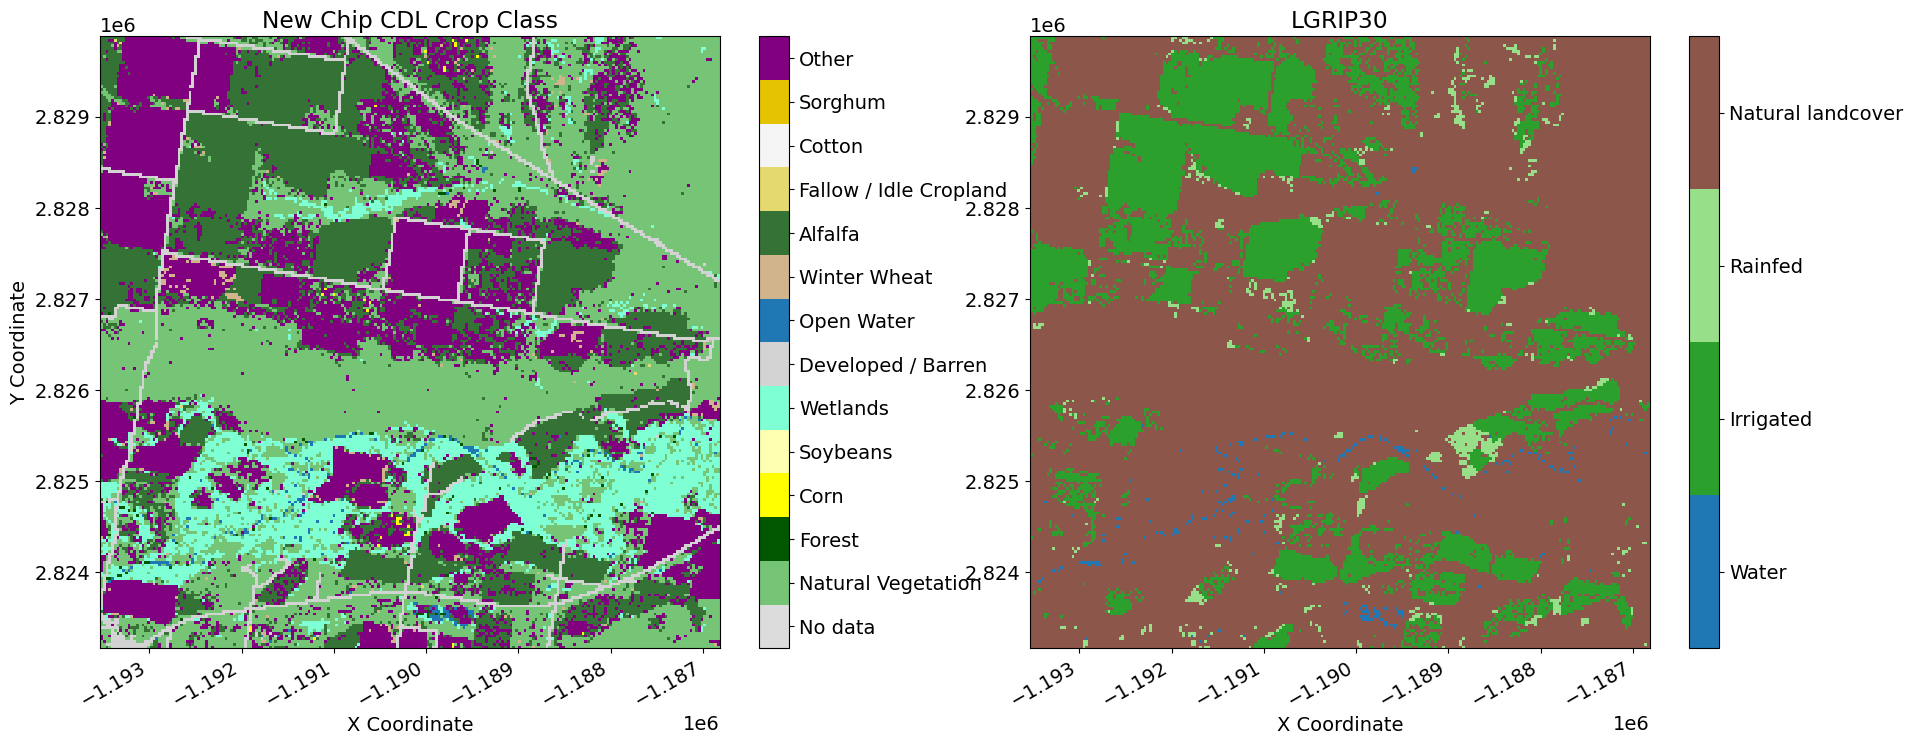

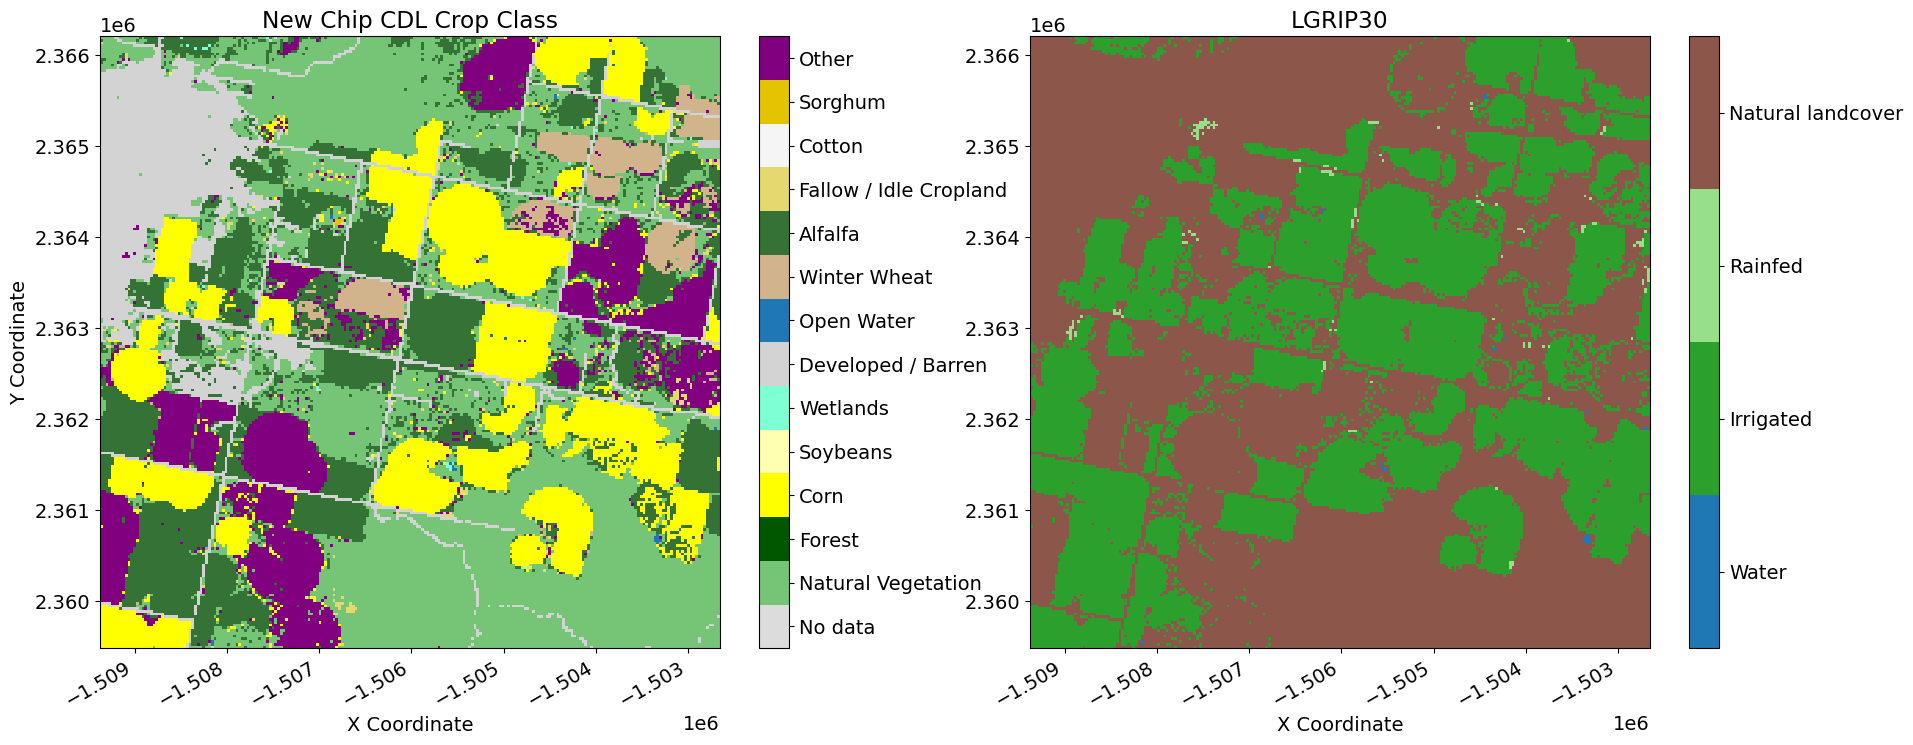

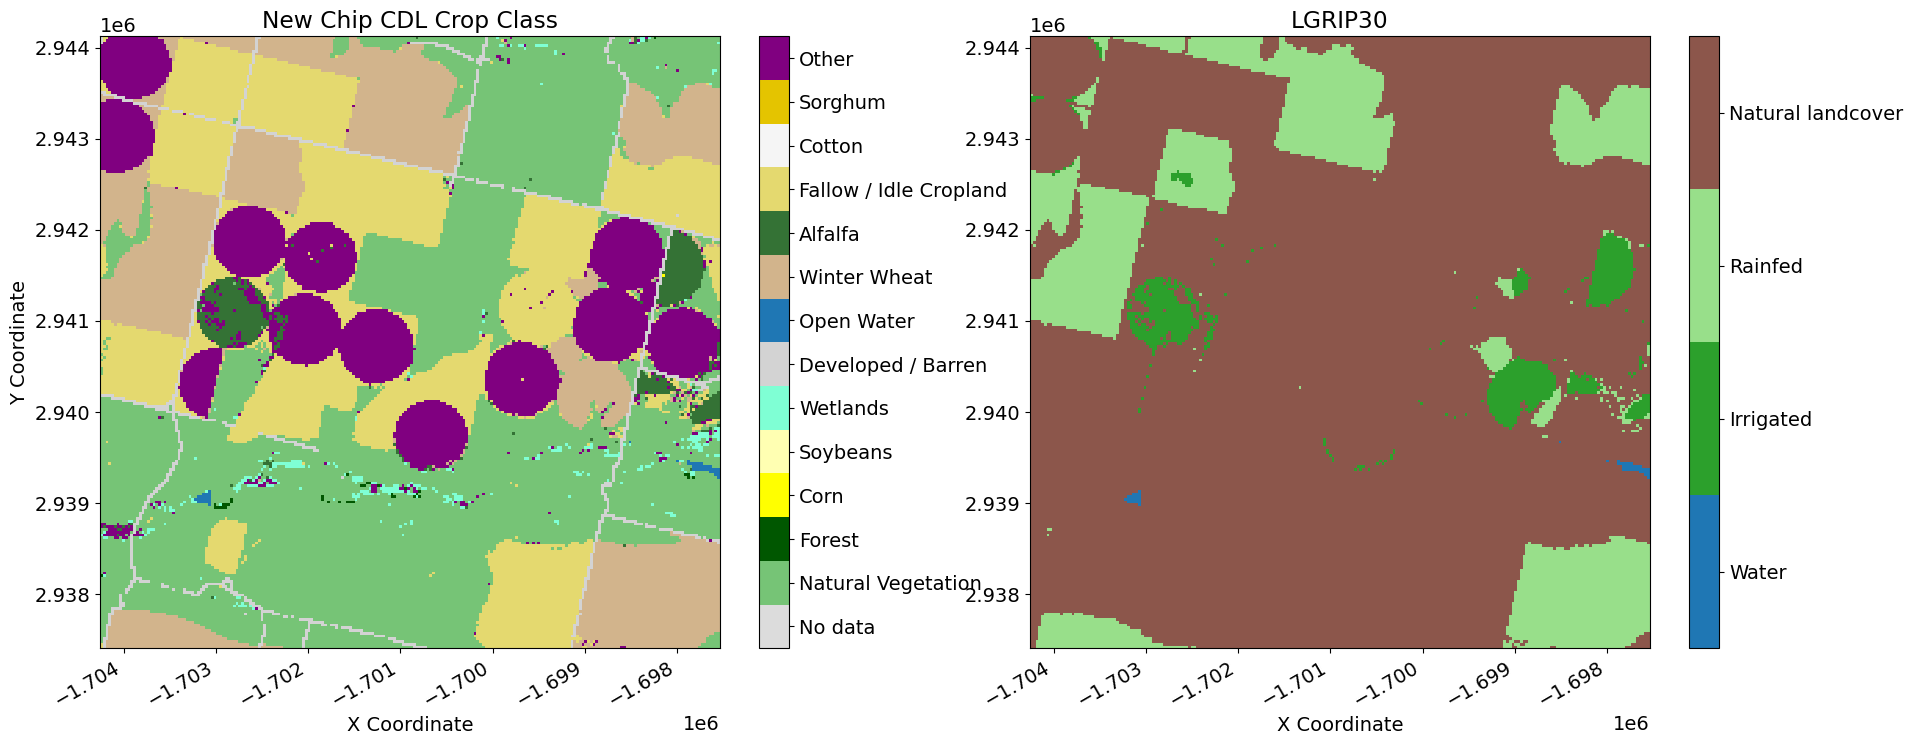

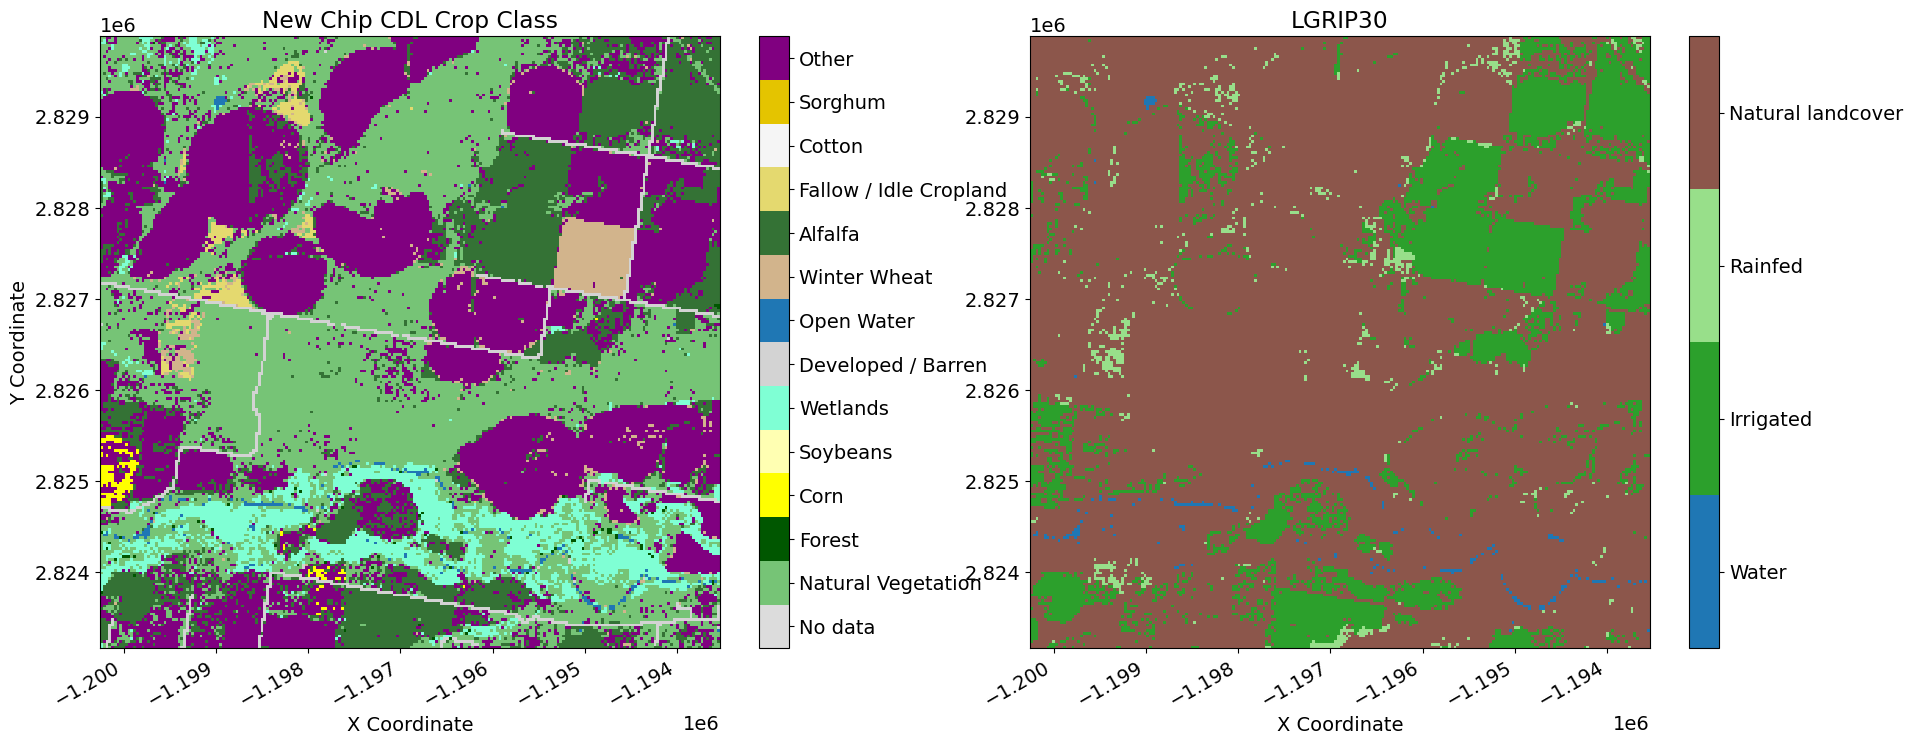

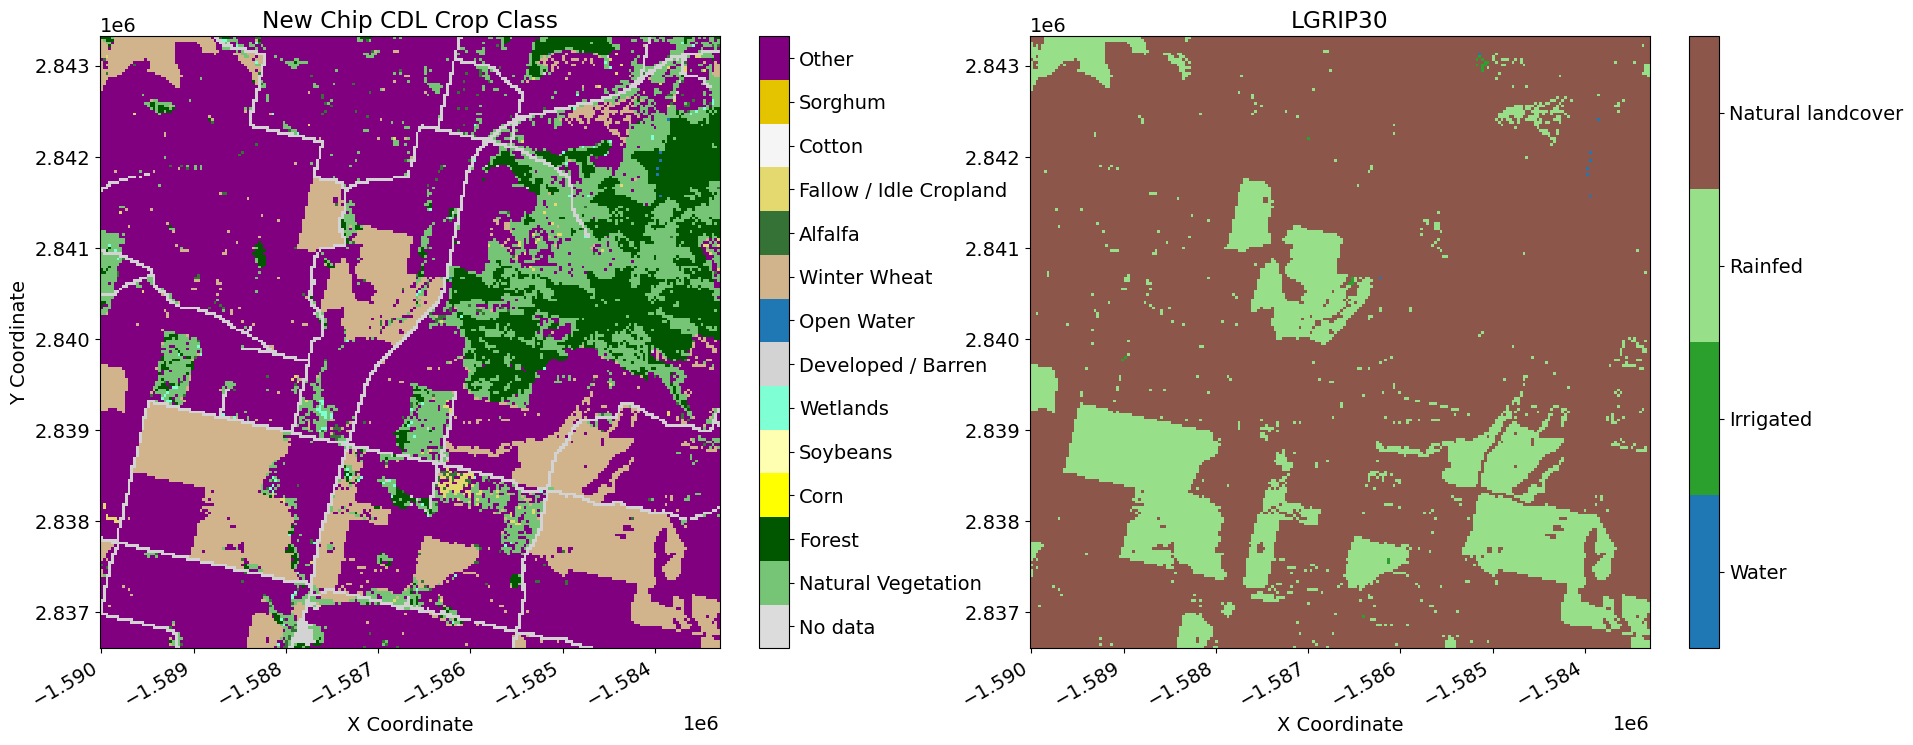

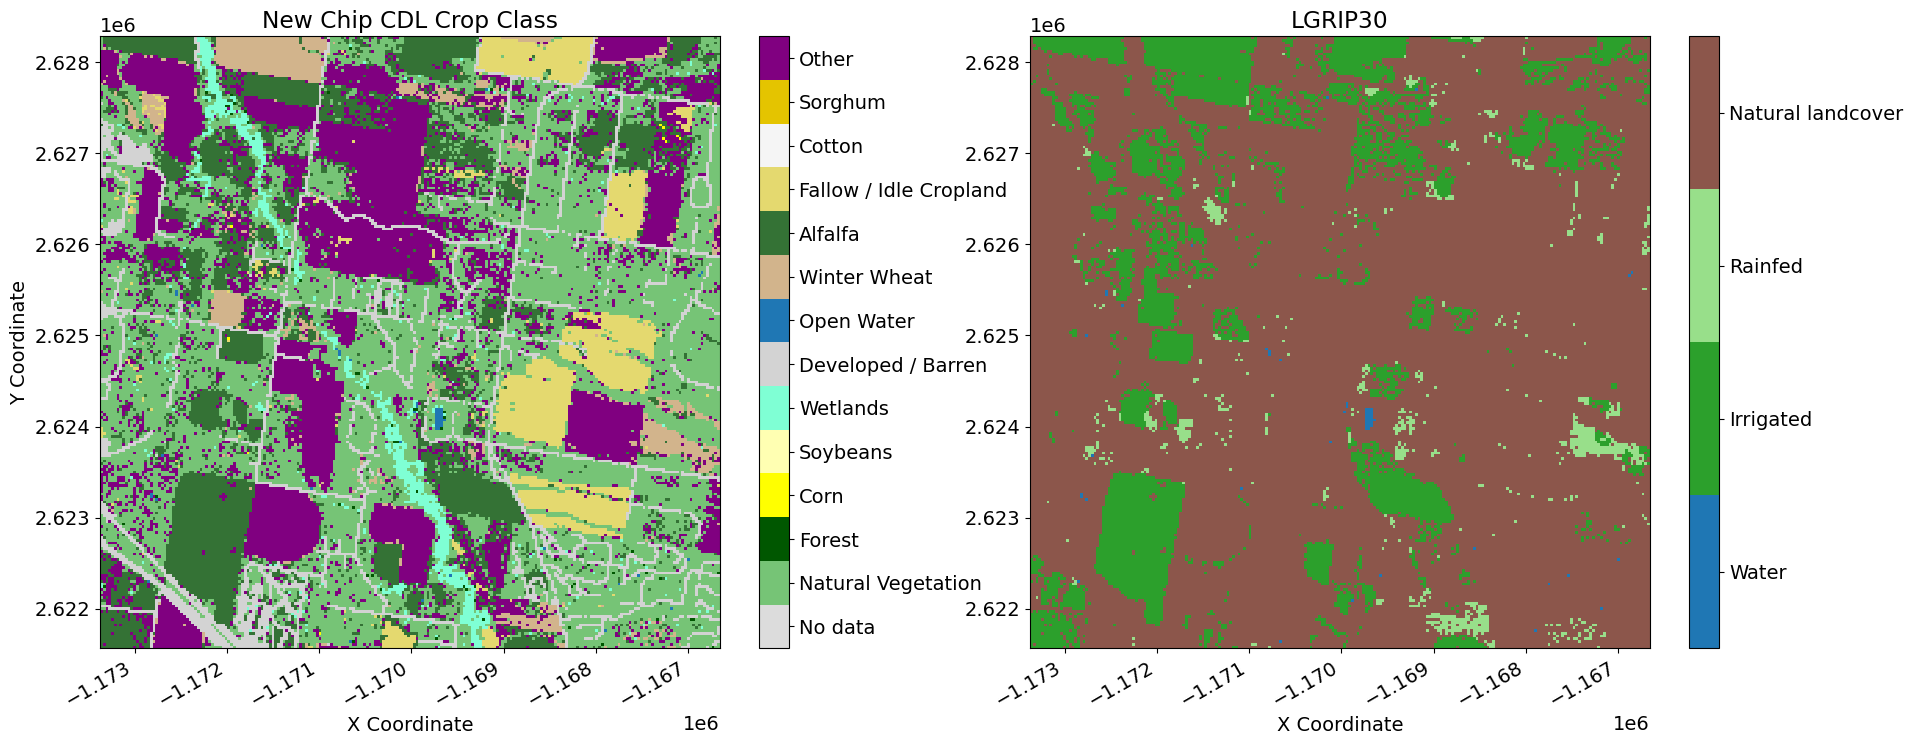

In [25]:
for i in range(6):
    
    fig, axes = plt.subplots(ncols=2, figsize=(22, 9))
    plt.rcParams.update({'font.size': 14})
    colors1 = [
    '#dcdcdc',  # No Data - light grey
    '#76c476',  # Natural Vegetation - light green
    '#005700',  # Forest - dark green
    '#ffff00',  # Corn - yellow
    '#ffffb2',  # Soybeans - pale yellow
    '#7fffd4',  # Wetlands - aquamarine
    '#d3d3d3',  # Developed / Barren - grey
    '#1f77b4',  # Open Water - blue
    '#d2b48c',  # Winter Wheat - light brown
    '#347235',  # Alfalfa - rich green
    '#e4d96f',  # Fallow / Idle Cropland - tan
    '#f5f5f5',  # Cotton - light grey
    '#e4c400',  # Sorghum - deep yellow
    '#800080']   # Other - purple
    
    cmap1 = ListedColormap(colors1)
    cdl_chip = rio.open_rasterio(path_df.chip_path.iloc[i])
    # Plot cdl
    im1 = cdl_chip.plot(
        x='x',
        cmap=cmap1,
        add_colorbar=False,
        ax=axes[0],
        vmin=-0.5,
        vmax=13.5
    )
    cbar1 = plt.colorbar(im1, ax=axes[0], ticks=np.arange(0, 14))
    cbar1.ax.set_yticklabels([
        "No data", "Natural Vegetation", "Forest", "Corn", "Soybeans", "Wetlands",
        "Developed / Barren", "Open Water", "Winter Wheat", "Alfalfa",
        "Fallow / Idle Cropland", "Cotton", "Sorghum", "Other"
    ])
    axes[0].set_title('New Chip CDL Crop Class')
    axes[0].set_xlabel('X Coordinate')
    axes[0].set_ylabel('Y Coordinate')
    
    colors2 = ['#1f77b4', '#2ca02c', '#98df8a' ,'#8c564b'] 
    cmap2 = plt.cm.colors.ListedColormap(colors2)
    ir_chip = rio.open_rasterio(path_df.output_path.iloc[i])
    
    # Plot the data
    im2 = ir_chip.plot(
        x='x',
        cmap=cmap2,
        add_colorbar=False,  # We'll add our own colorbar
        ax=axes[1],
        vmin = 0,
        vmax =3
    )
    
    # # Add a colorbar with custom labels
    cbar2 = plt.colorbar(im2, ax=axes[1], ticks=[0.375, 1.125, 1.875, 2.625])  # Center of each color band
    cbar2.ax.set_yticklabels(['Water','Irrigated', 'Rainfed', 'Natural landcover'])
    
    # Add title and labels
    plt.title('LGRIP30')
    plt.xlabel('X Coordinate')
    plt.ylabel('')
    fig.autofmt_xdate()

In [ ]:
overlaps['LGRIP30_L3_2020_N40W100_002_202408210000.tif']

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap
plt.rcParams.update({'font.size': 14})
colors = [
    '#dcdcdc',  # No Data - light grey
    '#76c476',  # Natural Vegetation - light green
    '#005700',  # Forest - dark green
    '#ffff00',  # Corn - yellow
    '#ffffb2',  # Soybeans - pale yellow
    '#7fffd4',  # Wetlands - aquamarine
    '#d3d3d3',  # Developed / Barren - grey
    '#1f77b4',  # Open Water - blue
    '#d2b48c',  # Winter Wheat - light brown
    '#347235',  # Alfalfa - rich green
    '#e4d96f',  # Fallow / Idle Cropland - tan
    '#f5f5f5',  # Cotton - light grey
    '#e4c400',  # Sorghum - deep yellow
    '#800080'   # Other - purple
]
cmap = plt.cm.colors.ListedColormap(colors)

for file in glob.glob(os.path.join(output_dir,'*.tif'))[:5]:
    # Create the plot
    fig, ax = plt.subplots(figsize=(9, 8))
    
    # Plot the data
    im = original_chip.plot(
        x='x',
        cmap=cmap,
        add_colorbar=False,  # We'll add our own colorbar
        ax=ax,
        vmin =-0.5,
        vmax =13.5
    )
    
    # # Add a colorbar with custom labels
    cbar = plt.colorbar(im, ax=ax, ticks=np.arange(0, 14))  # Center of each color band
    cbar.ax.set_yticklabels(["No data",
        "Natural Vegetation", "Forest", "Corn", "Soybeans", "Wetlands",
        "Developed / Barren", "Open Water", "Winter Wheat", "Alfalfa",
        "Fallow / Idle Cropland", "Cotton", "Sorghum", "Other"
    ])
    # Add title and labels
    plt.title('CDL Crop class')
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    fig.autofmt_xdate()
    # original_chip.plot(x = 'x')